##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** Databazen😎

**Student names & numbers:**
* [Xander UijtdeHaag] - [Student no.100546]
* [Jamie Eversdijk] - [Student no.000101617]
* [Jero den Exter] - [Student no.000100883]


---

## 0. Iteration setup

**Import libraries**

In [ ]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Load dataset(s)**

In [3]:
df = pd.read_csv('Data/ships_inventory_iter1.csv')

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the Nebula Brokerage pricing problem. Why is their current "gut feeling" approach a risk?.*

Nebula geeft de ruimteschepen nu een prijs op onderbuikgevoel. Dit zorgt ervoor dat ze veel geld verliezen. Zeldzame schepen worden te goedkoop verkocht en zijn dus underpriced en gewone schepen zijn te duur en dus overpriced, waardoor ze niet verkocht worden


**Business objective(s)**

*Justify why a data-driven baseline is needed*

Het doel van data-driven worden is om de overstap te maken van een subjectieve manier van keuzes maken naar een data-driven strategie. Als we een baseline prijs vast stellen, krijgt Nebula Brokerage een objectieve standaard prijs voor alle ruimteschepen. Dit zorgt ervoor dat er zo min mogelijk mensen fouten maken en voor zo min mogelijke inconsistenties tussen verschillende verkopers. Ook zorgt dit er voor dat nieuwe ruimteschepen sneller een prijs kunnen krijgen door te kijken naar de oude data, er is dus een basis. De overstap zorgt ook voor een goede start die we later kunnen gebruiken om complexe AI-modellen te bouwen die we kunnen gebruiken om de winst te maximaliseren.


**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

Dit is een regressie-taak. Het doel is om de Galactic_Credits te voorspellen door gebruik te maken van de beschikbare dataset. In onze eerste iteratie zoeken we naar de beste baseline. Dit betekent dat we een meting (zoals het gemiddelde of de mediaan) moeten bepalen die de kleinste afwijking heeft ten opzichte van de realistische verkoopprijzen


**Success criteria**

*Determine success criteria for this iteration (the benchmark)*

-De gekozen baseline moet zo min mogelijk fouten opleveren in vergelijking met de willekeurige schattingen die nu worden gedaan

-De gekozen waarde moet uit te leggen zijn aan de managers zodat ze gelijk vertrouwen in de nieuwe methode

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

De datatypes zijn int int float object en object. Wij hebben gekozen om de Galactic credits te gebruiken als een soort target. Dit is volgens ons de enige kolom die echt helpt bij het vinden van de juiste prijs van de schepen. De shipId is niet echt logisch om te gebruiken omdat het unieke waardes zijn van de schepen. De model cycle is ook niet logisch omdat het bouwjaar niet heel veel betekend voor ons doel. De andere kolommen zijn geen nummers en dus ook niet logisch

In [4]:
df.dtypes
df['Galactic_Credits'].describe()

count    368814.000000
mean      19453.536818
std       15540.472943
min         501.000000
25%        7950.000000
50%       15990.000000
75%       27990.000000
max      777777.000000
Name: Galactic_Credits, dtype: float64

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

Deze histogram is rechts scheef de staart zit rechts. Dit betekend dat bijna alle waardes links zitten en aan de rechter kant een aantal uitschieters zitten. Wij hebben er voor gekozen de waardes maar tot 100000 te laten gaan omdat de rest toch uitschieters zijn. Dit geeft alle data die echt belangrijk is duidelijk weer en zorgt ervoor dat de verdeling duidelijk zichtbaar is

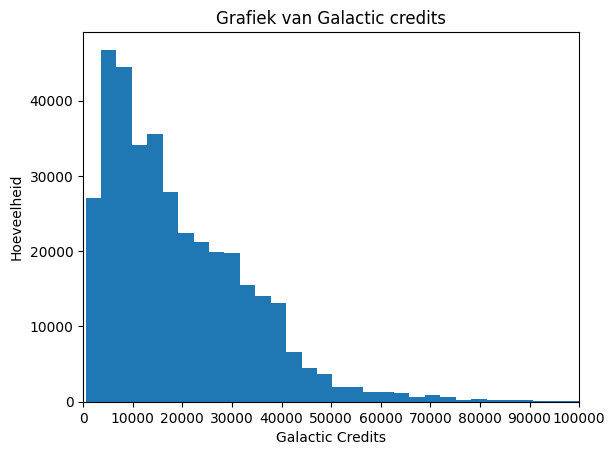

In [5]:
plt.hist(x=df['Galactic_Credits'], bins=250)
plt.title('Grafiek van Galactic credits')
plt.xlabel('Galactic Credits')
plt.ylabel('Hoeveelheid')
plt.xlim(0, 10000)
plt.xticks(range(0, 100001, 10000))
plt.show()

**Data insights and data quality**
* **Insights:** What are the key trends? What does the distribution look like? What does that mean? 
* **Quality issues:** Document missing values, duplicates, outliers, etc.

Er zijn veel missende gegevens in de Model_Cycle kolom. Dit betekend dat er een aantal schepen zijn waarvan het bouwjaar niet bekend is. Verder weten we dat er 500 rijen zijn die er 2 keer in staan. De typ fouten zitten in de ship_manufacturer het zijn vooral verkeerde afkortingen en een aantal cellen met dezelfde namen.

In [92]:
typfout = print(df['Ship_Manufacturer'].value_counts())

print(typfout)

Ship_Manufacturer
Independent Shipwrights        94444
Galactic Motors                57488
Corellian Engineering          44598
Kuat Drive Yards               27843
Hondo Systems                  19394
Jumpship Corp                  16803
Republic Aerospace             16191
General Mining Corp            15233
Nebula Industries              15125
Bayerische Motoren Wormhole    13327
Droid Works                    11685
Mercurian Benz                 10081
Independent                     3524
Ind. Shipwrights                3493
Independent Shipwright          3476
Corellian Engineering Corp      1656
Corelian Engineering            1650
Corellian Eng.                  1647
Galactic_Motors                 1636
Galactic Motrs                  1600
GALACTIC MOTORS                 1592
Galactic Motors                 1555
Kuat Drive                      1034
Kuat DY                         1030
Kuat  Drive Yards               1027
Nebula                           589
Nebula Industries (c

In [91]:

duplicatie = df.duplicated().sum()

print(duplicatie)

500


In [90]:
missend = df.isna().sum()

print(missend)

Ship_ID                       0
Galactic_Credits              0
Model_Cycle                7406
Ship_Manufacturer             0
Sector                        0
Ship_Manufacturer_clean       0
dtype: int64


---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

Eerst doen we de duplicaten weg, vervolgens doen we de uitschieters boven 100.000 weg zodat het gemiddelde meer betrouwbaar is. Vervolgens doen we de rijen me missende bouwjaren weg zodat er alleen maar rijen zijn met volledige info. Als laatst zorgen we dat de manufacturers goed staan met str.strip() en replace()

In [4]:
print(f"Start vorm: {df.shape}")

df_nodupe = df.drop_duplicates()
print(f"Na duplicaten weg: {df_nodupe.shape}")

df_nodupe = df_nodupe[df_nodupe['Galactic_Credits'] < 100000]
print(f"Na outliers weg: {df_nodupe.shape}")

df_nodupe = df_nodupe.dropna(subset=['Model_Cycle'])
print(f"Na dropna: {df_nodupe.shape}")

df_nodupe['Ship_Manufacturer'] = df_nodupe['Ship_Manufacturer'].str.strip()

mapping = {
    'Independent': 'Independent Shipwrights',
    'Ind. Shipwrights': 'Independent Shipwrights',
    'Independent Shipwright': 'Independent Shipwrights',
    'Corellian Engineering Corp': 'Corellian Engineering',
    'Corelian Engineering': 'Corellian Engineering',
    'Corellian Eng.': 'Corellian Engineering',
    'Galactic_Motors': 'Galactic Motors',
    'Galactic Motrs': 'Galactic Motors',
    'GALACTIC MOTORS': 'Galactic Motors',
    'Kuat Drive': 'Kuat Drive Yards',
    'Kuat DY': 'Kuat Drive Yards',
    'Kuat  Drive Yards': 'Kuat Drive Yards',
    'Nebula': 'Nebula Industries',
    'Nebula Industries (c)': 'Nebula Industries',
    'Nebula Ind': 'Nebula Industries'
}

df_nodupe['Ship_Manufacturer'] = df_nodupe['Ship_Manufacturer'].replace(mapping)

df_final = df_nodupe

print("\nEindresultaat Fabrikanten")
print(df_final['Ship_Manufacturer'].value_counts())

print("\nEindstatistieken Credits")
print(df_final['Galactic_Credits'].describe().to_string())

df_final.to_csv('Data/ships_inventory_cleaned_v1.csv', index=False)

Start vorm: (368814, 5)
Na duplicaten weg: (368314, 5)
Na outliers weg: (367691, 5)
Na dropna: (360306, 5)

Eindresultaat Fabrikanten
Ship_Manufacturer
Independent Shipwrights        102492
Galactic Motors                 62470
Corellian Engineering           48315
Kuat Drive Yards                30239
Hondo Systems                   18989
Jumpship Corp                   16432
Nebula Industries               16429
Republic Aerospace              15804
General Mining Corp             14901
Bayerische Motoren Wormhole     13045
Droid Works                     11386
Mercurian Benz                   9804
Name: count, dtype: int64

Eindstatistieken Credits
count    360306.000000
mean      19232.728903
std       14286.210766
min         501.000000
25%        7950.000000
50%       15990.000000
75%       27990.000000
max       99999.000000


**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [5]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [21]:
# CODE CELL: Model training and setup code
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# De target is galacric credits wat we gaan voorspellen
target = df['Galactic_Credits']
# We splitsen de data in een train en test set
target_train, target_test = train_test_split(target, test_size=0.2, random_state=42)

# Hier is de voorspelling van het model
value = target_train.mean()

pred_train = [value] * len(target_train)

pred_test = [value] * len(target_test)

Hierin wordt de voorspelling gemaakt met train_test_split wat wordt opgedeeld in 80% train en 20% split wat de test_size=0.2 aangeeft. De random state is 42 wat aangeeft dat het altijd hetzelfde wordt verdeeld en je het vaker opnieuw kan gebruiken. Tot slot maak je de voorspelling van de train d.m.v. het gemiddelde te pakken van de target en dat * target_train en -test te doen.

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [ ]:
# CODE CELL: Model evaluation code
# MAE en MSE van train en test
print('MAE of train set:', mean_absolute_error(target_train, pred_train))
print('MAE of test set:', mean_absolute_error(target_test, pred_test))
print('MSE of train set:', mean_squared_error(target_train, pred_train))
print('MSE of test set:', mean_squared_error(target_test, pred_test))

MAE of train set: 11598.093996749569
MAE of test set: 11639.005957472937
MSE of train set: 238417125.75637788
MSE of test set: 253859769.8236507


MAE en MSE van de train is de daadwerkelijke waardes van Galactic_Credits en de test is de voorspelling ervan. De MAE van de trainingsset is ongeveer 11.598 en van de testset ongeveer 11.639. Het verschil van 40 Galactic_Credits is zeer klein, wat aangeeft dat het model niet ver afwijkt. Het verschil in MSE tussen train en test is ongeveer 15 miljoen. Dit lijkt veel maar aangezien de waardes gekwadrateerd worden valt dit wel mee, zeker met deze dataset dus wijkt dit ook niet veel af van het originele.

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*What is the difference between the metrics? What does this mean? Did you meet the goals set in the Business Understanding?*
Wij hebben de mean absolute error en de mean squared error gebruikt om te kijken hoeveel de voorspelde en echte waardes afwijken van elkaar. De mean absolute error heeft het verschil tussen de train 11.598 en 11.639 dit is een klein verschil en is dus goed. Wij wijken weinig af van de echte waardes. De mse heeft een iets groter verschil van ongeveer 15 miljoen. Dit komt waarschijnlijk door een aantal uitschieters die de waarde zo hoog maken. Wij denken dat onze methode goed genoeg is, maar wel beter kan.


**Key findings and limitations**
*What did you learn? What are the limitations of this current model?*
Wij hebben geleerd dat ons model een aantal goede delen heeft. Het is een klein verschil bij het mae. Dit is goed, want het model wijkt niet ver af van de werkelijkheid. Het levert goede resultaten op. Het levert meer betrouwbaarheid op dan het onderbuikgevoel wat hiervoor is gebruikt. De nadelen zijn dat er nog steeds uitschieters in zitten die de waardes aanpassen. Het gebruikt ook alleen de galactic credits kolom wat wel kan omdat het de target is, maar het kan wel beter.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Xander UijtdeHaag | Business understanding, Data preperation, Evaluation | Ik heb veel geleerd over het belang en het nut van Data-driven worden en het doel van data-driven worden als bedrijf. Ook heb ik technisch veel geleerd bij Data preperation en dit lukte na wat dingen uitzoeken best makkelijk. Ook heb ik veel geleerd over hoe de opdracht eruit ziet en hoe data science een beetje in elkaar zit |
| Jamie Eversdrijk | Modeling, Evaluation | Ik heb geleerd hoe je met een baseline model en een train-test split een eerlijk nulpunt bepaalt voor de voorspellingen. Door het gemiddelde te gebruiken en dit te testen met MAE en MSE, heb ik geleerd hoe je de stabiliteit en fouten van een model meetbaar maakt |
| Jero den Exter | Data understanding, Data preperation, Evaluation | Veel geleerd over het werken met een grote dataset. Het data preperation gedeelte vond ik wel lastig. Geleerd over data understanding en alle handige python commands daarbij |